<a href="https://www.kaggle.com/code/gpreda/infant-wellness-and-risk-evaluation?scriptVersionId=264496477" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction

With this Notebook we will evaluate the [Infant Wellness and Risk Evaluation Dataset](https://www.kaggle.com/datasets/mubeenshehzadi/infant-wellness-and-risk-evaluation-dataset).

# Prepare analysis

## Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read and glimpse the data

In [2]:
df = pd.read_csv("/kaggle/input/infant-wellness-and-risk-evaluation-dataset/newborn_health_monitoring_with_risk.csv", low_memory=False)

Let's make sure we do not see the ugly display warning.

In [3]:
pd.set_option("display.float_format", "{:.6f}".format)

In [4]:
df.head()

,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
0,B001,Sara,Female,40.200000,3.300000,50.000000,31.900000,2024-12-10,1,3.280000,...,98,Formula,11,9,0,4.200000,7.000000,Yes,Yes,At Risk
1,B001,Sara,Female,40.200000,3.300000,50.000000,31.900000,2024-12-11,2,3.350000,...,99,Formula,11,5,2,10.600000,NaN,No,No,At Risk
2,B001,Sara,Female,40.200000,3.300000,50.000000,31.900000,2024-12-12,3,3.350000,...,97,Breastfeeding,7,6,5,9.800000,NaN,No,No,Healthy
3,B001,Sara,Female,40.200000,3.300000,50.000000,31.900000,2024-12-13,4,3.480000,...,97,Mixed,11,8,4,8.100000,NaN,No,Yes,Healthy
4,B001,Sara,Female,40.200000,3.300000,50.000000,31.900000,2024-12-14,5,3.500000,...,96,Breastfeeding,11,7,1,11.600000,NaN,No,Yes,At Risk


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   baby_id                      3000 non-null   object 
 1   name                         3000 non-null   object 
 2   gender                       3000 non-null   object 
 3   gestational_age_weeks        3000 non-null   float64
 4   birth_weight_kg              3000 non-null   float64
 5   birth_length_cm              3000 non-null   float64
 6   birth_head_circumference_cm  3000 non-null   float64
 7   date                         3000 non-null   object 
 8   age_days                     3000 non-null   int64  
 9   weight_kg                    3000 non-null   float64
 10  length_cm                    3000 non-null   float64
 11  head_circumference_cm        3000 non-null   float64
 12  temperature_c                3000 non-null   float64
 13  heart_rate_bpm    

In [6]:
df.describe()

,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,age_days,weight_kg,length_cm,head_circumference_cm,temperature_c,heart_rate_bpm,respiratory_rate_bpm,oxygen_saturation,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,100.000000
mean,38.878000,3.205000,49.727000,34.128000,15.500000,3.669730,50.508000,34.438900,37.002933,139.682000,39.421333,97.473000,9.450000,6.470000,2.448333,4.163467,8.400000
std,1.570076,0.561555,2.145065,1.486254,8.656884,0.621355,2.196846,1.500893,0.310747,10.139386,4.999481,1.048318,1.707182,1.700803,1.699106,2.861971,1.163415
min,35.400000,1.860000,45.100000,31.200000,1.000000,1.790000,45.000000,31.100000,35.800000,100.000000,23.000000,94.000000,7.000000,4.000000,0.000000,0.000000,7.000000
25%,37.800000,2.870000,48.475000,32.975000,8.000000,3.220000,49.100000,33.300000,36.800000,133.000000,36.000000,97.000000,8.000000,5.000000,1.000000,2.500000,7.000000
50%,38.800000,3.165000,49.550000,34.100000,15.500000,3.660000,50.400000,34.400000,37.000000,140.000000,39.000000,97.000000,9.000000,6.000000,2.000000,3.300000,8.000000
75%,40.100000,3.625000,51.025000,34.800000,23.000000,4.100000,51.800000,35.300000,37.200000,146.000000,43.000000,98.000000,11.000000,8.000000,4.000000,4.300000,9.250000
max,43.000000,4.470000,55.800000,38.100000,30.000000,5.410000,57.400000,38.700000,38.100000,173.000000,57.000000,101.000000,12.000000,9.000000,5.000000,15.000000,10.000000


# Data preprocessing


Before further analysing the data, we perform some  basic preprocessing:
- Converting datetime format
- Unifying NaN formats
- Convert possible numeric fields to numeric format
- Make risk levels categorical

In [7]:
if df["date"].dtype == "object":
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [8]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [9]:
numeric_cols = [
    "gestational_age_weeks","birth_weight_kg","birth_length_cm",
    "birth_head_circumference_cm","age_days","weight_kg","length_cm",
    "head_circumference_cm","temperature_c","heart_rate_bpm",
    "respiratory_rate_bpm","oxygen_saturation","feeding_frequency_per_day",
    "urine_output_count","stool_count","jaundice_level_mg_dl","apgar_score"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [10]:
if "risk_level" in df.columns:
    order = ["Healthy", "At Risk", "Critical"]
    present = [r for r in order if r in df["risk_level"].unique()]
    df["risk_level"] = pd.Categorical(df["risk_level"], categories=present, ordered=True)


# Data analysis

Let's do few summary statistics on the data, before going to visualizations.

In [11]:
print("Rows:", len(df))
print("Babies:", df["baby_id"].nunique())
print("Date range:", df["date"].min(), "→", df["date"].max())

Rows: 3000
Babies: 100
Date range: 2024-08-23 00:00:00 → 2025-09-17 00:00:00


## Mismatching per columns

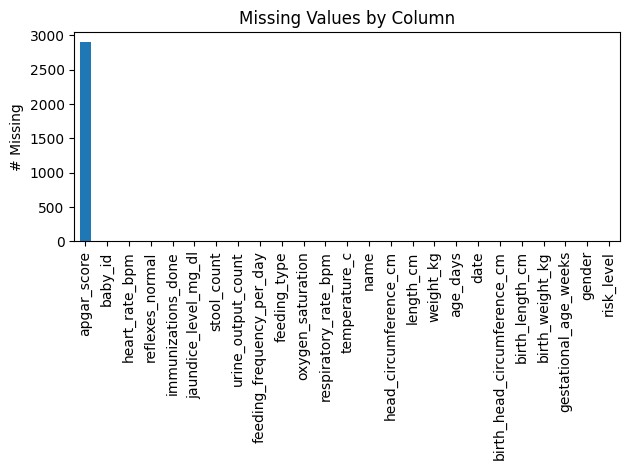

In [12]:
missing = df.isna().sum().sort_values(ascending=False)
plt.figure()
missing.plot(kind="bar")
plt.title("Missing Values by Column")
plt.ylabel("# Missing")
plt.tight_layout()
plt.show()

Only 100 babies have apgar score available.

# Data visualization

## Weight at birth

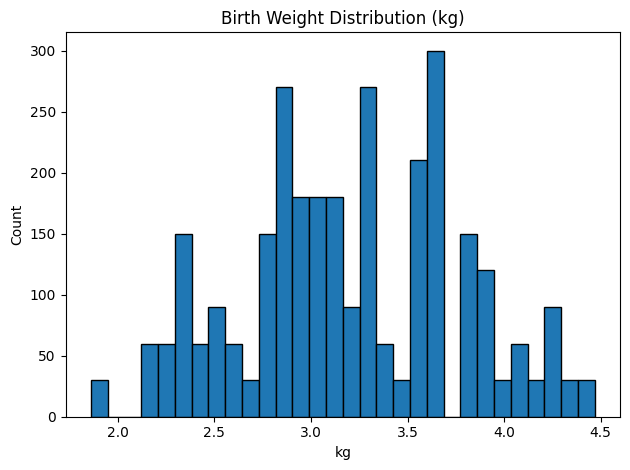

In [13]:
plt.figure()
df["birth_weight_kg"].dropna().plot(kind="hist", bins=30, edgecolor="black")
plt.title("Birth Weight Distribution (kg)")
plt.xlabel("kg")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Temperature distribution

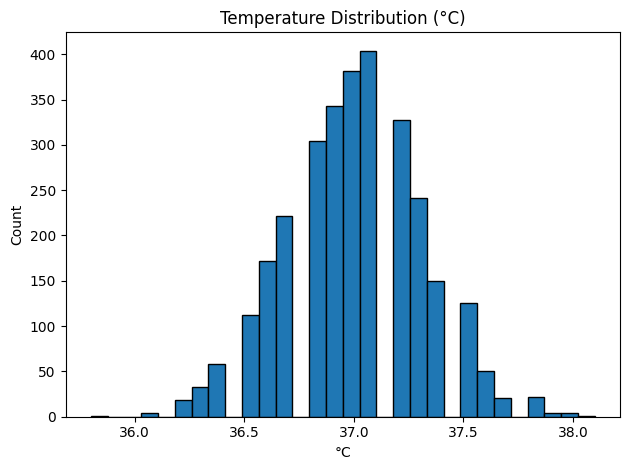

In [14]:
plt.figure()
df["temperature_c"].dropna().plot(kind="hist", bins=30, edgecolor="black")
plt.title("Temperature Distribution (°C)")
plt.xlabel("°C")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Feeding type frequencies

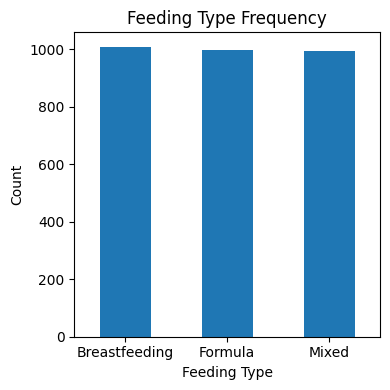

In [15]:
plt.figure(figsize=(4,4))
df["feeding_type"].value_counts(dropna=False).plot(kind="bar")
plt.title("Feeding Type Frequency")
plt.xlabel("Feeding Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Weight by risk level

In [16]:
# Build data in risk-level order to avoid category gaps
data_for_box = [d.dropna().values for _, d in df.sort_values("risk_level").groupby("risk_level")["weight_kg"]]
labels = [str(k) for k in df["risk_level"].cat.categories] if hasattr(df["risk_level"], "cat") else list(df["risk_level"].unique())

/tmp/ipykernel_13/2259965124.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_for_box = [d.dropna().values for _, d in df.sort_values("risk_level").groupby("risk_level")["weight_kg"]]


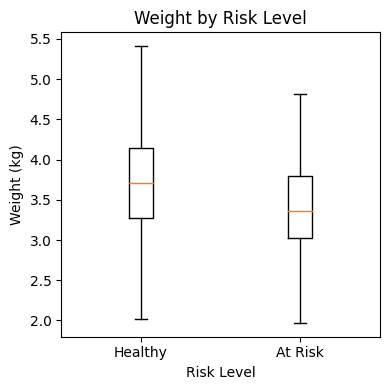

In [17]:
plt.figure(figsize=(4,4))
plt.boxplot(data_for_box, labels=labels, showfliers=False)
plt.title("Weight by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Weight (kg)")
plt.tight_layout()
plt.show()

## Average weight across age (population)

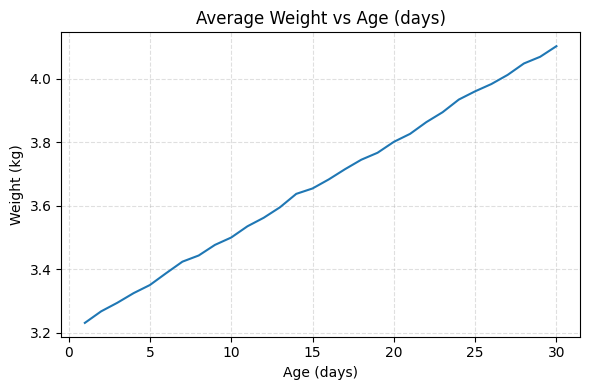

In [18]:
avg_weight = df.groupby("age_days", as_index=False)["weight_kg"].mean().sort_values("age_days")
plt.figure(figsize=(6,4))
plt.plot(avg_weight["age_days"], avg_weight["weight_kg"])
plt.title("Average Weight vs Age (days)")
plt.xlabel("Age (days)")
plt.ylabel("Weight (kg)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Weight vs Age, split by gender

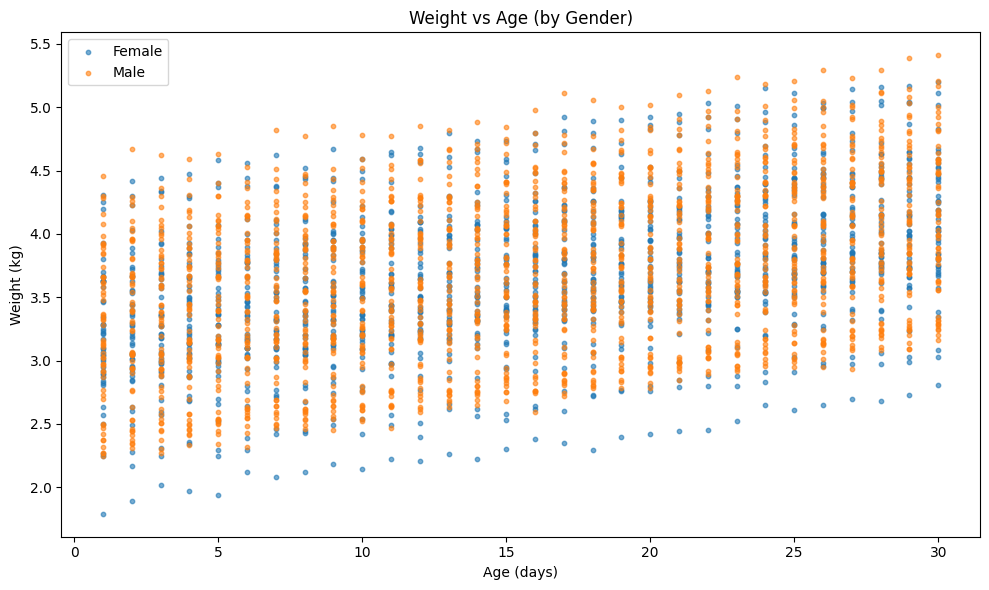

In [19]:
plt.figure(figsize=(10,6))
genders = df["gender"].dropna().unique().tolist()
for g in genders:
    sub = df[df["gender"] == g]
    plt.scatter(sub["age_days"], sub["weight_kg"], s=10, alpha=0.6, label=str(g))
plt.title("Weight vs Age (by Gender)")
plt.xlabel("Age (days)")
plt.ylabel("Weight (kg)")
plt.legend()
plt.tight_layout()
plt.show()

## Jaundice over age with simple threshold line

In [20]:
avg_jaundice = df.groupby("age_days", as_index=False)["jaundice_level_mg_dl"].mean().sort_values("age_days")

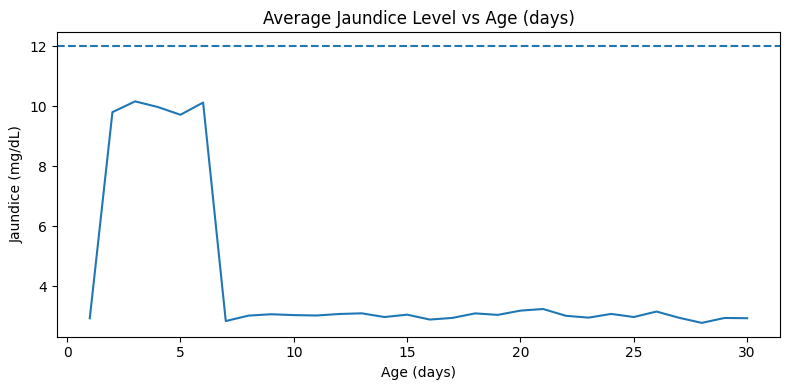

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(avg_jaundice["age_days"], avg_jaundice["jaundice_level_mg_dl"])
# Simple illustrative threshold (should be personalized based on protocol)
thresh = 12.0
plt.axhline(thresh, linestyle="--")
plt.title("Average Jaundice Level vs Age (days)")
plt.xlabel("Age (days)")
plt.ylabel("Jaundice (mg/dL)")
plt.tight_layout()
plt.show()

## Per-baby time series

In [22]:
def plot_baby_timeseries(df, baby_id, columns=("weight_kg","length_cm","head_circumference_cm","temperature_c")):
    """
    One chart per metric for a given baby_id.
    Usage:
        plot_baby_timeseries(df, "B001")
    """
    sub = df[df["baby_id"] == baby_id].copy()
    if sub.empty:
        print(f"No rows for baby_id={baby_id!r}")
        return
    # sort by age or date if available
    if "age_days" in sub.columns:
        sub.sort_values("age_days", inplace=True)
        x = sub["age_days"]; xlab = "Age (days)"
    else:
        sub.sort_values("date", inplace=True)
        x = sub["date"]; xlab = "Date"

    for col in columns:
        if col in sub.columns:
            plt.figure(figsize=(8, 3))
            plt.plot(x, sub[col])
            plt.title(f"{col} over time — baby {baby_id}")
            plt.xlabel(xlab)
            plt.ylabel(col)
            if pd.api.types.is_numeric_dtype(sub[col]):
                plt.grid(True, linestyle="--", alpha=0.4)
            plt.tight_layout()
            plt.show()


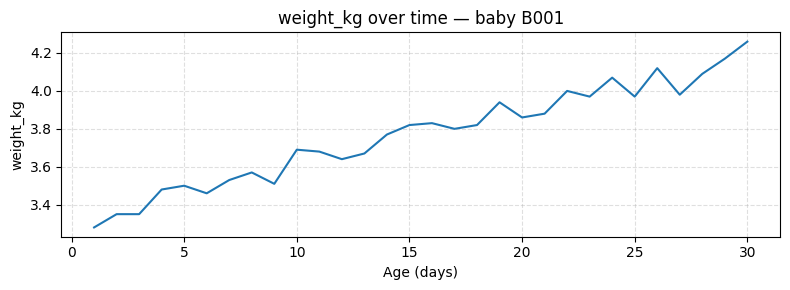

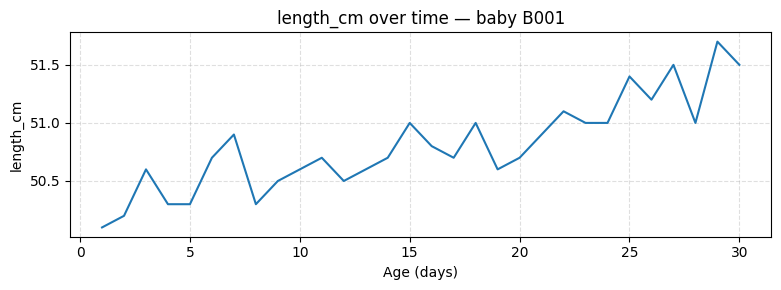

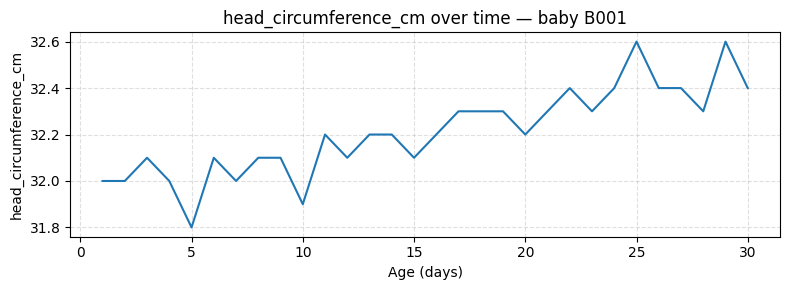

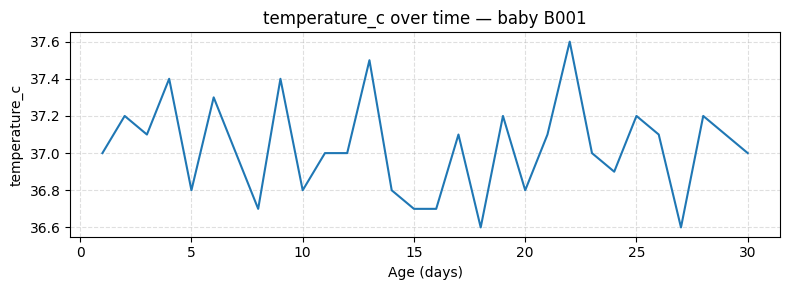

In [23]:
plot_baby_timeseries(df, "B001")

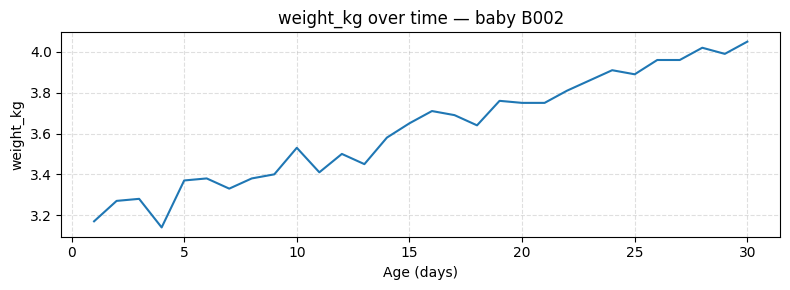

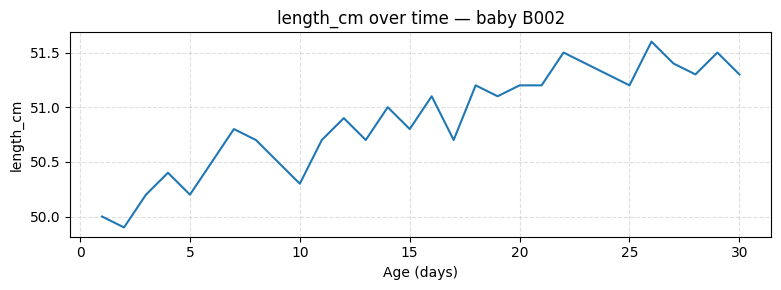

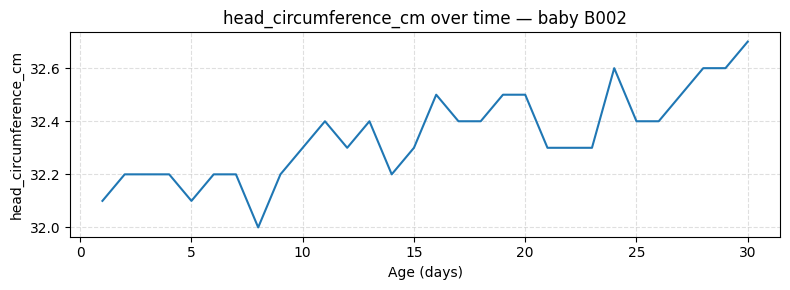

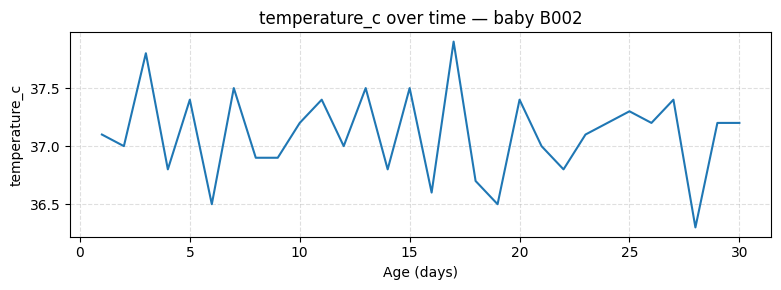

In [24]:
plot_baby_timeseries(df, "B002")

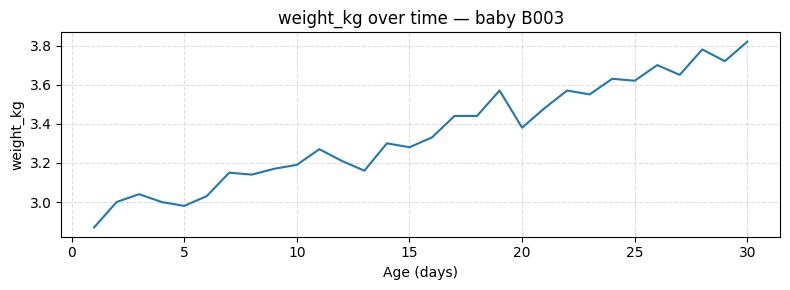

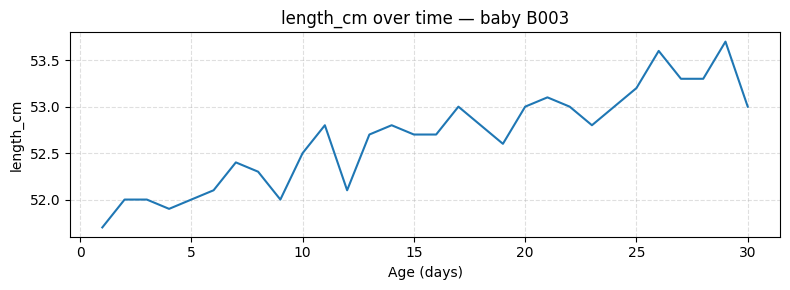

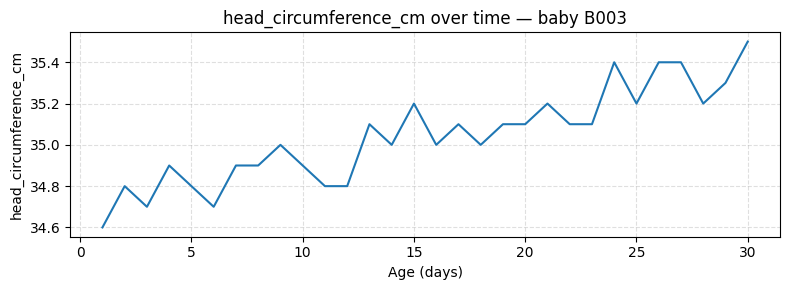

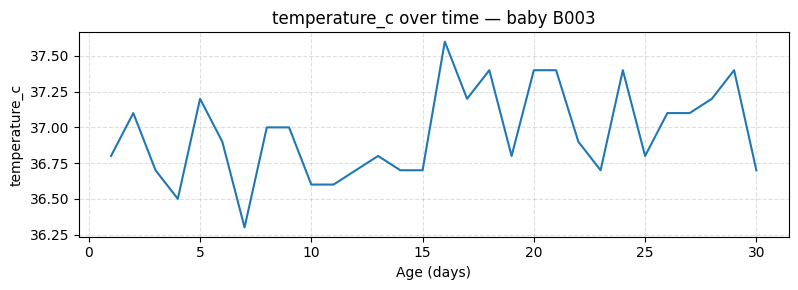

In [25]:
plot_baby_timeseries(df, "B003")

## Feeding type vs. risk level

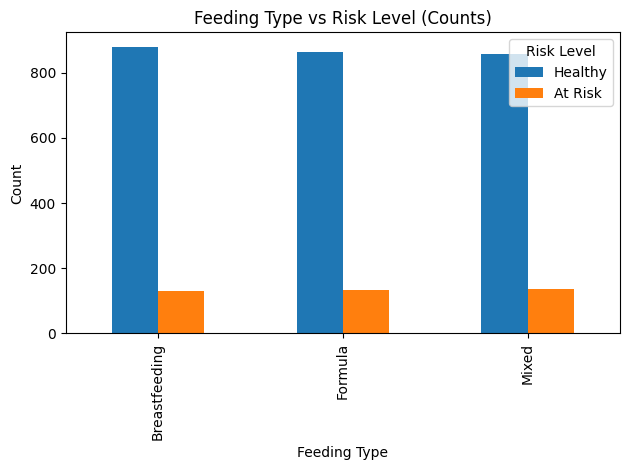

In [26]:
cross = pd.crosstab(df["feeding_type"], df["risk_level"])
cross.plot(kind="bar", stacked=False)
plt.title("Feeding Type vs Risk Level (Counts)")
plt.xlabel("Feeding Type")
plt.ylabel("Count")
plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

## Feeding type vs. risk level (proportions plot)

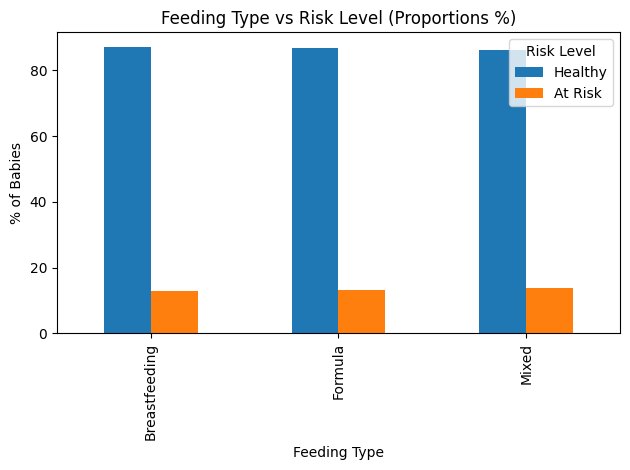

In [27]:
(cross.div(cross.sum(axis=1), axis=0) * 100).plot(kind="bar")
plt.title("Feeding Type vs Risk Level (Proportions %)")
plt.xlabel("Feeding Type")
plt.ylabel("% of Babies")
plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

## Gender vs Risk Level

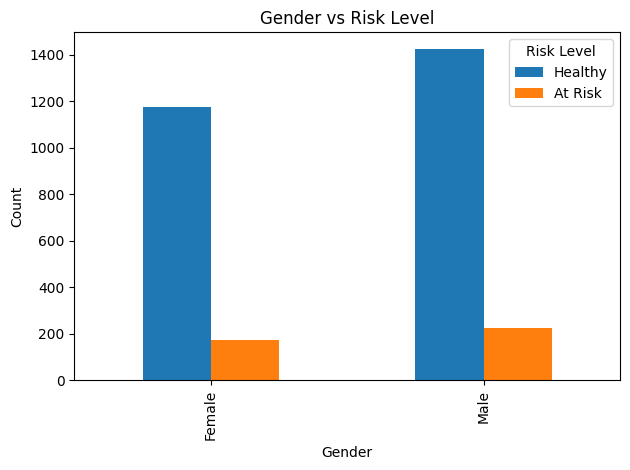

In [28]:
cross_gender = pd.crosstab(df["gender"], df["risk_level"])
cross_gender.plot(kind="bar")
plt.title("Gender vs Risk Level")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

## Average vitals vs. risk level

/tmp/ipykernel_13/1351944284.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_vitals = df.groupby("risk_level")[vitals].mean()


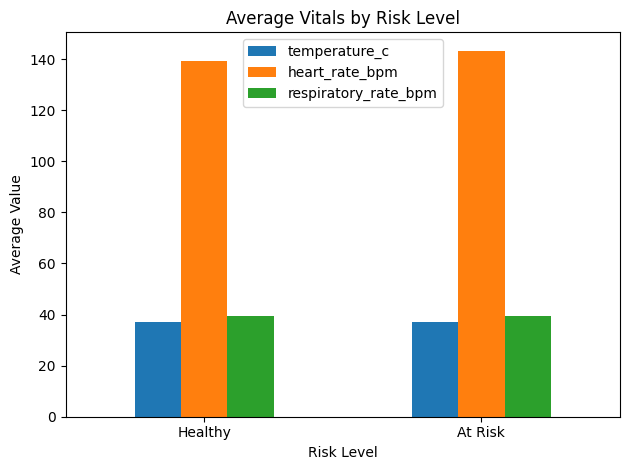

In [29]:
vitals = ["temperature_c","heart_rate_bpm","respiratory_rate_bpm"]
avg_vitals = df.groupby("risk_level")[vitals].mean()

avg_vitals.plot(kind="bar")
plt.title("Average Vitals by Risk Level")
plt.ylabel("Average Value")
plt.xlabel("Risk Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Feeding Type vs Average Jaundice

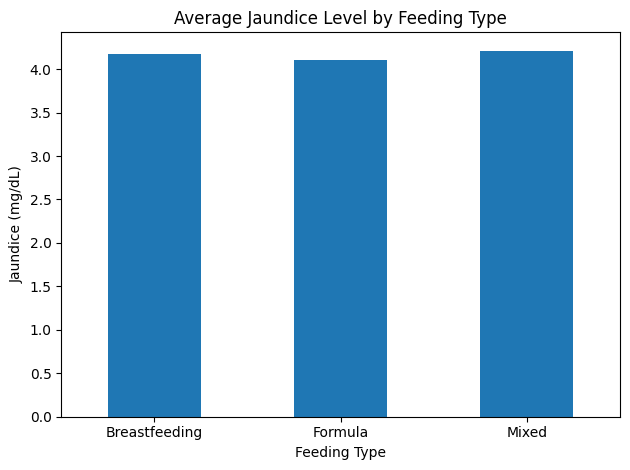

In [30]:
avg_jaundice = df.groupby("feeding_type")["jaundice_level_mg_dl"].mean()
avg_jaundice.plot(kind="bar")
plt.title("Average Jaundice Level by Feeding Type")
plt.xlabel("Feeding Type")
plt.ylabel("Jaundice (mg/dL)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Feeding × Risk × Age (Heatmap-style with pivot)

/tmp/ipykernel_13/3815534449.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


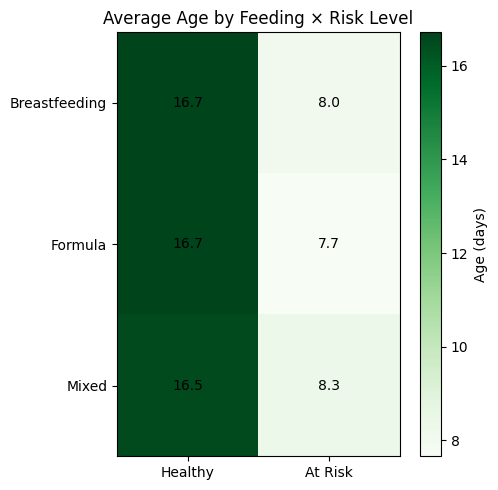

In [31]:
pivot = df.pivot_table(
    index="feeding_type",
    columns="risk_level",
    values="age_days",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(pivot.fillna(0).values, cmap="Greens")

# show ticks
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)
plt.title("Average Age by Feeding × Risk Level")

# label values on heatmap
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        ax.text(j, i, f"{val:.1f}" if not np.isnan(val) else "NA",
                ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, label="Age (days)")
plt.tight_layout()
plt.show()

# Final remarks


We analysed this dataset, starting with preprocessing the data, and then performing univariate and bi-variate analysis.

Feel free to suggest further improvements to this work.